In [4]:

import pandas as pd

visits = pd.read_csv('data/visits_log_us.csv')
orders = pd.read_csv('data/orders_log_us.csv')
costs = pd.read_csv('data/costs_us.csv')



In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar os dados
visits = pd.read_csv('data/visits_log_us.csv')
orders = pd.read_csv('data/orders_log_us.csv')
costs = pd.read_csv('data/costs_us.csv')

# Normalizar colunas PRIMEIRO (antes de qualquer outra coisa)
orders.columns = orders.columns.str.strip().str.lower().str.replace(' ', '_')
visits.columns = visits.columns.str.strip().str.lower().str.replace(' ', '_')
costs.columns  = costs.columns.str.strip().str.lower().str.replace(' ', '_')

# Visits: datas de início e fim da sessão
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts']   = pd.to_datetime(visits['end_ts'])
visits['session_duration'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds()

# Orders
orders['buy_ts']  = pd.to_datetime(orders['buy_ts'])
orders['revenue'] = pd.to_numeric(orders['revenue'], errors='coerce')

# Costs
costs['dt']    = pd.to_datetime(costs['dt'])
costs['costs'] = pd.to_numeric(costs['costs'], errors='coerce')

# source_id como string
visits['source_id'] = visits['source_id'].astype(str)
costs['source_id']  = costs['source_id'].astype(str)

# Verificação final
for name, df in [('VISITS', visits), ('ORDERS', orders), ('COSTS', costs)]:
    print(f"\n{'='*50}")
    print(f"  {name}  —  {df.shape[0]} linhas x {df.shape[1]} colunas")
    print('='*50)
    print(df.dtypes)
    print(f"\nAmostra:")
    print(df.head(3))
    print(f"\nNulos: {df.isnull().sum().sum()}")


  VISITS  —  359400 linhas x 6 colunas
device                      object
end_ts              datetime64[ns]
source_id                   object
start_ts            datetime64[ns]
uid                         uint64
session_duration           float64
dtype: object

Amostra:
    device              end_ts source_id            start_ts  \
0    touch 2017-12-20 17:38:00         4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00         2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00         5 2017-07-01 01:54:00   

                    uid  session_duration  
0  16879256277535980062            1080.0  
1    104060357244891740            1680.0  
2   7459035603376831527               0.0  

Nulos: 0

  ORDERS  —  50415 linhas x 3 colunas
buy_ts     datetime64[ns]
revenue           float64
uid                uint64
dtype: object

Amostra:
               buy_ts  revenue                   uid
0 2017-06-01 00:10:00    17.00  10329302124590727494
1 2017-06-01 00:25:00     0.55  1162

In [6]:
print("VISITS:", visits.columns.tolist())
print("ORDERS:", orders.columns.tolist())
print("COSTS:", costs.columns.tolist())


VISITS: ['device', 'end_ts', 'source_id', 'start_ts', 'uid', 'session_duration']
ORDERS: ['buy_ts', 'revenue', 'uid']
COSTS: ['source_id', 'dt', 'costs']


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

════════════════════════════════════════
  PEDIDOS POR PERÍODO
════════════════════════════════════════
Média diária  : 139 pedidos/dia
Média semanal : 951 pedidos/semana
Média mensal  : 3878 pedidos/mês

════════════════════════════════════════
  TICKET MÉDIO
════════════════════════════════════════
Média   : $5.00
Mediana : $2.50
Máximo  : $2633.28

════════════════════════════════════════
  TEMPO ATÉ PRIMEIRA COMPRA
════════════════════════════════════════
Média   : 16.9 dias
Mediana : 0.0 dias
Compras no mesmo dia (<=1d) : 26367


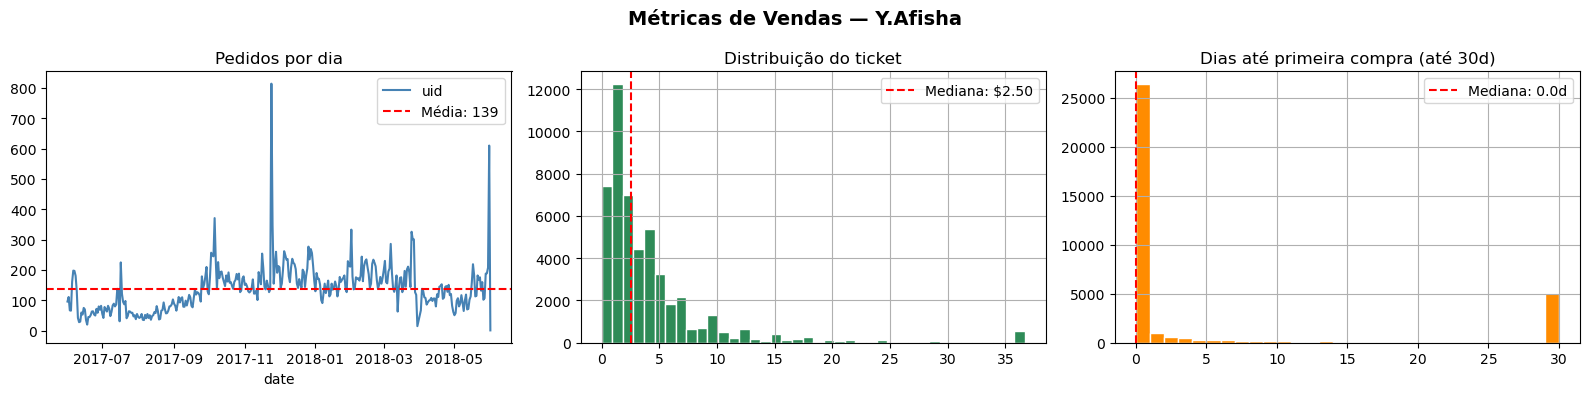

In [8]:


orders.columns = orders.columns.str.strip().str.lower().str.replace(' ', '_')
visits.columns = visits.columns.str.strip().str.lower().str.replace(' ', '_')
costs.columns  = costs.columns.str.strip().str.lower().str.replace(' ', '_')

# Converter para datetime após renomear
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts']   = pd.to_datetime(visits['end_ts'])
costs['dt']        = pd.to_datetime(costs['dt'])

# Duração da sessão (caso não exista ainda)
if 'session_duration' not in visits.columns:
    visits['session_duration'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds()

# ── PEDIDOS POR PERÍODO ───────────────────────────────────────────────────────
orders['date']  = orders['buy_ts'].dt.date
orders['week']  = orders['buy_ts'].dt.to_period('W')
orders['month'] = orders['buy_ts'].dt.to_period('M')

orders_per_day   = orders.groupby('date')['uid'].count()
orders_per_week  = orders.groupby('week')['uid'].count()
orders_per_month = orders.groupby('month')['uid'].count()

print("═"*40)
print("  PEDIDOS POR PERÍODO")
print("═"*40)
print(f"Média diária  : {orders_per_day.mean():.0f} pedidos/dia")
print(f"Média semanal : {orders_per_week.mean():.0f} pedidos/semana")
print(f"Média mensal  : {orders_per_month.mean():.0f} pedidos/mês")

# ── TICKET MÉDIO ──────────────────────────────────────────────────────────────
print("\n" + "═"*40)
print("  TICKET MÉDIO")
print("═"*40)
print(f"Média   : ${orders['revenue'].mean():.2f}")
print(f"Mediana : ${orders['revenue'].median():.2f}")
print(f"Máximo  : ${orders['revenue'].max():.2f}")

# ── TEMPO ATÉ PRIMEIRA COMPRA ─────────────────────────────────────────────────
first_visit = visits.groupby('uid')['start_ts'].min().reset_index()
first_visit.columns = ['uid', 'first_visit_ts']

first_order = orders.groupby('uid')['buy_ts'].min().reset_index()
first_order.columns = ['uid', 'first_order_ts']

conversion = first_visit.merge(first_order, on='uid')
conversion['days_to_buy'] = (conversion['first_order_ts'] - conversion['first_visit_ts']).dt.total_seconds() / 86400

print("\n" + "═"*40)
print("  TEMPO ATÉ PRIMEIRA COMPRA")
print("═"*40)
print(f"Média   : {conversion['days_to_buy'].mean():.1f} dias")
print(f"Mediana : {conversion['days_to_buy'].median():.1f} dias")
print(f"Compras no mesmo dia (<=1d) : {(conversion['days_to_buy'] <= 1).sum()}")

# ── GRÁFICOS ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Métricas de Vendas — Y.Afisha', fontsize=14, fontweight='bold')

orders_per_day.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Pedidos por dia')
axes[0].axhline(orders_per_day.mean(), color='red', linestyle='--', label=f'Média: {orders_per_day.mean():.0f}')
axes[0].legend()

orders['revenue'].clip(upper=orders['revenue'].quantile(0.99)).hist(bins=40, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Distribuição do ticket')
axes[1].axvline(orders['revenue'].median(), color='red', linestyle='--', label=f'Mediana: ${orders["revenue"].median():.2f}')
axes[1].legend()

conversion['days_to_buy'].clip(upper=30).hist(bins=30, ax=axes[2], color='darkorange', edgecolor='white')
axes[2].set_title('Dias até primeira compra (até 30d)')
axes[2].axvline(conversion['days_to_buy'].median(), color='red', linestyle='--', label=f'Mediana: {conversion["days_to_buy"].median():.1f}d')
axes[2].legend()

plt.tight_layout()
plt.show()
print("\n")

In [9]:
import pandas as pd

# Carregar
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs  = pd.read_csv('/datasets/costs_us.csv')

# Normalizar colunas
orders.columns = orders.columns.str.strip().str.lower().str.replace(' ', '_')
visits.columns = visits.columns.str.strip().str.lower().str.replace(' ', '_')
costs.columns  = costs.columns.str.strip().str.lower().str.replace(' ', '_')

# Converter datas
orders['buy_ts']   = pd.to_datetime(orders['buy_ts'])
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts']   = pd.to_datetime(visits['end_ts'])
costs['dt']        = pd.to_datetime(costs['dt'])

# Confirmar
print("VISITS:", visits.columns.tolist())
print("ORDERS:", orders.columns.tolist())
print("COSTS:", costs.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '/datasets/visits_log_us.csv'

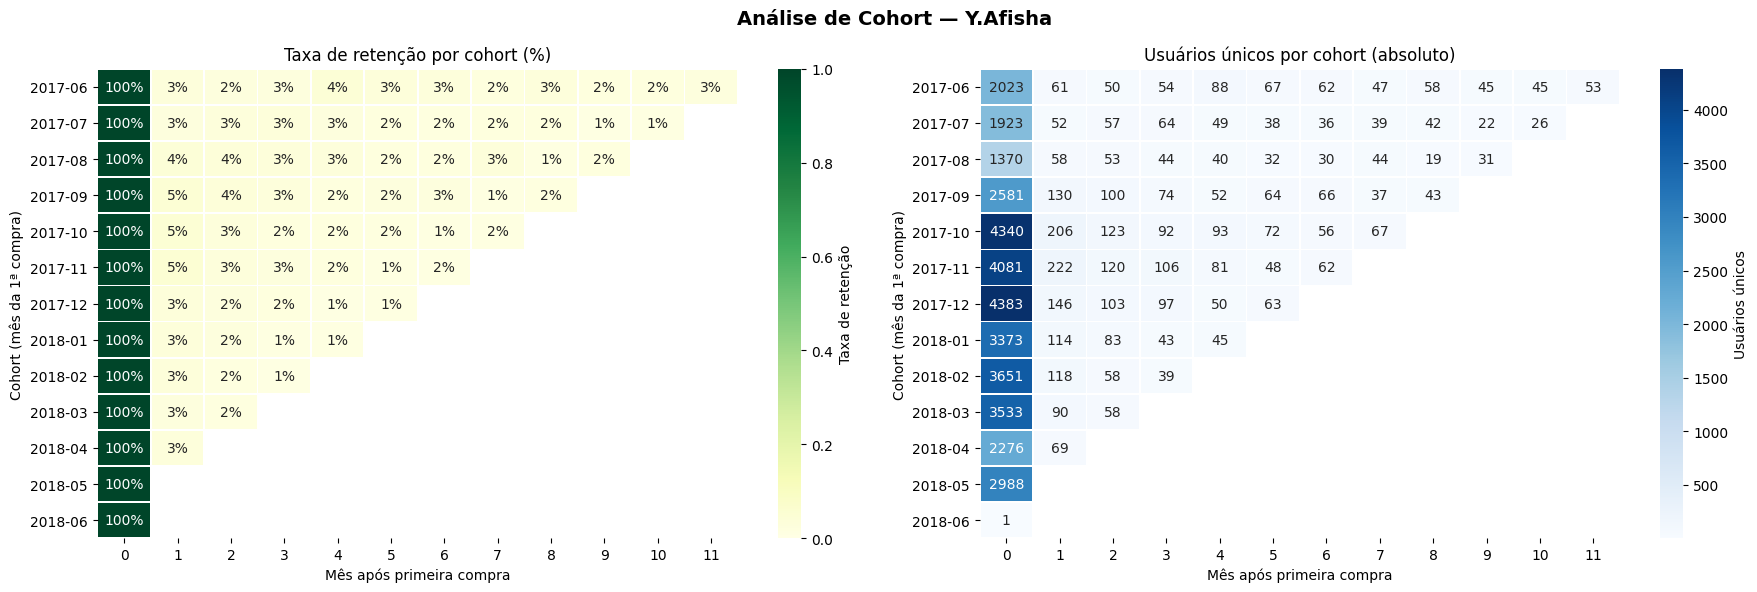

══════════════════════════════════════════════════
  RETENÇÃO MÉDIA POR MÊS (todos os cohorts)
══════════════════════════════════════════════════
  Mês  0 : 100.0%
  Mês  1 : 3.7%
  Mês  2 : 2.7%
  Mês  3 : 2.4%
  Mês  4 : 2.3%
  Mês  5 : 2.1%
  Mês  6 : 2.1%
  Mês  7 : 2.1%
  Mês  8 : 2.0%
  Mês  9 : 1.9%
  Mês 10 : 1.8%
  Mês 11 : 2.6%


In [ ]:
if 'session_duration' not in visits.columns:
    visits['session_duration'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds()

# ── ANÁLISE DE COHORT ─────────────────────────────────────────────────────────

# 1. Cohort de cada usuário = mês da primeira compra
first_order = orders.groupby('uid')['buy_ts'].min().reset_index()
first_order.columns = ['uid', 'first_order_ts']
first_order['cohort'] = first_order['first_order_ts'].dt.to_period('M')

# 2. Juntar cohort às ordens
orders_cohort = orders.merge(first_order[['uid', 'cohort']], on='uid')

# 3. Calcular índice do mês dentro do cohort
orders_cohort['order_period'] = orders_cohort['buy_ts'].dt.to_period('M')
orders_cohort['cohort_index'] = (
    orders_cohort['order_period'] - orders_cohort['cohort']
).apply(lambda x: x.n)

# 4. Tabela pivô: usuários únicos por (cohort, cohort_index)
cohort_data = (
    orders_cohort
    .groupby(['cohort', 'cohort_index'])['uid']
    .nunique()
    .reset_index()
)
cohort_pivot = cohort_data.pivot(index='cohort', columns='cohort_index', values='uid')

# 5. Taxa de retenção
cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0)

# ── VISUALIZAÇÃO ──────────────────────────────────────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Análise de Cohort — Y.Afisha', fontsize=14, fontweight='bold')

sns.heatmap(
    retention.iloc[:, :12],
    ax=axes[0], annot=True, fmt='.0%',
    cmap='YlGn', linewidths=0.5, linecolor='white',
    vmin=0, vmax=1, cbar_kws={'label': 'Taxa de retenção'}
)
axes[0].set_title('Taxa de retenção por cohort (%)')
axes[0].set_xlabel('Mês após primeira compra')
axes[0].set_ylabel('Cohort (mês da 1ª compra)')
axes[0].yaxis.set_tick_params(rotation=0)

sns.heatmap(
    cohort_pivot.iloc[:, :12],
    ax=axes[1], annot=True, fmt='.0f',
    cmap='Blues', linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Usuários únicos'}
)
axes[1].set_title('Usuários únicos por cohort (absoluto)')
axes[1].set_xlabel('Mês após primeira compra')
axes[1].set_ylabel('Cohort (mês da 1ª compra)')
axes[1].yaxis.set_tick_params(rotation=0)

plt.tight_layout()
plt.show()

# ── RESUMO ────────────────────────────────────────────────────────────────────
print("═"*50)
print("  RETENÇÃO MÉDIA POR MÊS (todos os cohorts)")
print("═"*50)
for month, rate in retention.mean().items():
    if month <= 11:
        print(f"  Mês {month:2d} : {rate:.1%}")

Análise de Cohort — Retenção de Clientes

A análise de cohort agrupa os usuários pelo mês de sua primeira compra e mede quantos deles voltaram a comprar nos meses seguintes.

Os resultados revelam um padrão preocupante: a retenção cai drasticamente logo após o primeiro mês. Em média, apenas 3,7% dos clientes retornam no mês seguinte à primeira compra (Mês 1), e esse percentual continua caindo gradualmente até estabilizar em torno de 2% ao mês entre os meses 2 e 10.
Isso indica que a grande maioria dos clientes realiza apenas uma única compra e não retorna. O negócio depende fortemente da aquisição contínua de novos clientes para manter o volume de vendas, o que torna o custo de aquisição um fator crítico para a rentabilidade.
O leve aumento no Mês 11 (2,6%) pode ser um artefato estatístico — cohorts mais antigos têm menos meses de observação disponíveis, o que pode distorcer a média nesse ponto.
Recomendação: investigar estratégias de retenção (cupons de recompra, e-mail marketing, programa de fidelidade) para aumentar o retorno após a primeira compra, especialmente no intervalo crítico do Mês 1.


Análise — Métricas de Vendas
Pedidos por Período
139 pedidos/dia em média
951 pedidos/semana
3.878 pedidos/mês
Comparando com o DAU de 908 usuários/dia, a taxa de conversão diária é de aproximadamente 15% — ou seja, nem todo visitante compra no mesmo dia que acessa.

Ticket Médio

Mediana: $2,50 — valor mais representativo, produto de baixo custo
Média: $5,00 — puxada por outliers (máximo de $2.633)
A grande diferença entre média e mediana indica poucos pedidos de alto valor distorcendo a média

Tempo até Primeira Compra

Mediana: 0 dias — a maioria dos usuários que compram, compram no mesmo dia da primeira visita
26.367 usuários converteram em até 1 dia — conversão rápida!
Média de 16,9 dias puxada por usuários que demoram muito mais

Isso é um sinal muito positivo: o produto converte rápido quem tem intenção de compra. A estratégia de marketing deve focar em trazer o usuário certo, pois uma vez que ele chega, tende a comprar no mesmo dia.

In [ ]:
# ── LTV, CAC e ROI por Cohort ─────────────────────────────────────────────────

# ETAPA 1: Primeiro pedido por usuário + mês do cohort
first_order = (
    orders.groupby('uid')['buy_ts']
    .min()
    .reset_index()
)
first_order.columns = ['uid', 'first_order_ts']
first_order['cohort_month'] = first_order['first_order_ts'].dt.to_period('M')

# ETAPA 2: Conectar usuário com origem (source_id da primeira visita)
first_visit = (
    visits.sort_values('start_ts')
    .groupby('uid')
    .first()
    .reset_index()[['uid', 'source_id']]
)

# Juntar cohort + origem
user_info = first_order.merge(first_visit, on='uid', how='left')

# ETAPA 3: Receita mensal por usuário
orders['order_month'] = orders['buy_ts'].dt.to_period('M')
revenue_per_user = (
    orders.groupby(['uid', 'order_month'])['revenue']
    .sum()
    .reset_index()
)

# ETAPA 4: Agrupar receita e custos por origem e mês
# Receita: juntar com user_info para trazer source_id e cohort_month
revenue_full = revenue_per_user.merge(user_info[['uid', 'source_id', 'cohort_month']], on='uid', how='left')

revenue_by_source = (
    revenue_full.groupby(['cohort_month', 'source_id'])['revenue']
    .sum()
    .reset_index()
)

# Custos: agrupar por mês e source_id
costs['month'] = costs['dt'].dt.to_period('M')
costs_by_source = (
    costs.groupby(['month', 'source_id'])['costs']
    .sum()
    .reset_index()
)
costs_by_source.columns = ['cohort_month', 'source_id', 'costs']

# ETAPA 5: Tabela final combinando receita e custos
ltv_cac = revenue_by_source.merge(costs_by_source, on=['cohort_month', 'source_id'], how='left')

# Número de usuários por cohort e origem (para calcular LTV e CAC por cliente)
users_per_cohort = (
    user_info.groupby(['cohort_month', 'source_id'])['uid']
    .nunique()
    .reset_index()
)
users_per_cohort.columns = ['cohort_month', 'source_id', 'n_users']

ltv_cac = ltv_cac.merge(users_per_cohort, on=['cohort_month', 'source_id'], how='left')

# Calcular métricas
ltv_cac['LTV'] = ltv_cac['revenue'] / ltv_cac['n_users']
ltv_cac['CAC'] = ltv_cac['costs']   / ltv_cac['n_users']
ltv_cac['ROI'] = (ltv_cac['revenue'] - ltv_cac['costs']) / ltv_cac['costs']

# Exibir resultado
print(ltv_cac[['cohort_month', 'source_id', 'costs', 'revenue', 'n_users', 'LTV', 'CAC', 'ROI']]
      .sort_values(['cohort_month', 'source_id'])
      .to_string(index=False))

cohort_month  source_id    costs  revenue  n_users       LTV       CAC       ROI
     2017-06          1  1125.61  6392.39      190 33.644158  5.924263  4.679045
     2017-06          2  2427.38  3915.26      235 16.660681 10.329277  0.612957
     2017-06          3  7731.65  3640.32      638  5.705831 12.118574 -0.529166
     2017-06          4  3514.80  4992.67      413 12.088789  8.510412  0.420471
     2017-06          5  2616.12  4377.64      384 11.400104  6.812813  0.673333
     2017-06          9   285.22   472.15       68  6.943382  4.194412  0.655389
     2017-06         10   314.22   241.26       95  2.539579  3.307579 -0.232194
     2017-07          1  1072.88  3342.52      160 20.890750  6.705500  2.115465
     2017-07          2  2333.11  2357.57      208 11.334471 11.216875  0.010484
     2017-07          3  7674.37  3761.04      512  7.345781 14.989004 -0.509922
     2017-07          4  3529.73  3246.62      517  6.279729  6.827331 -0.080207
     2017-07          5  299

════════════════════════════════════════
  GASTOS TOTAIS COM MARKETING
════════════════════════════════════════
Total gasto : $329,131.62
Média mensal: $27,427.63

Gasto por origem:
source_id
3     $141,321.63
4      $61,073.60
5      $51,757.10
2      $42,806.04
1      $20,833.27
10      $5,822.49
9       $5,517.49
Name: costs, dtype: object

════════════════════════════════════════
  CAC POR ORIGEM
════════════════════════════════════════
  Origem 9: $3.90 por cliente
  Origem 10: $4.69 por cliente
  Origem 1: $5.57 por cliente
  Origem 4: $6.22 por cliente
  Origem 5: $7.57 por cliente
  Origem 2: $9.90 por cliente
  Origem 3: $15.47 por cliente

════════════════════════════════════════
  ROI POR ORIGEM (%)
════════════════════════════════════════
  ✅ Origem 1: 85.1%
  ✅ Origem 2: 52.2%
  ✅ Origem 9: 28.3%
  ❌ Origem 4: -14.1%
  ❌ Origem 5: -22.0%
  ❌ Origem 10: -29.4%
  ❌ Origem 3: -68.6%

════════════════════════════════════════
  LTV MÉDIO POR ORIGEM
═════════════════════════════

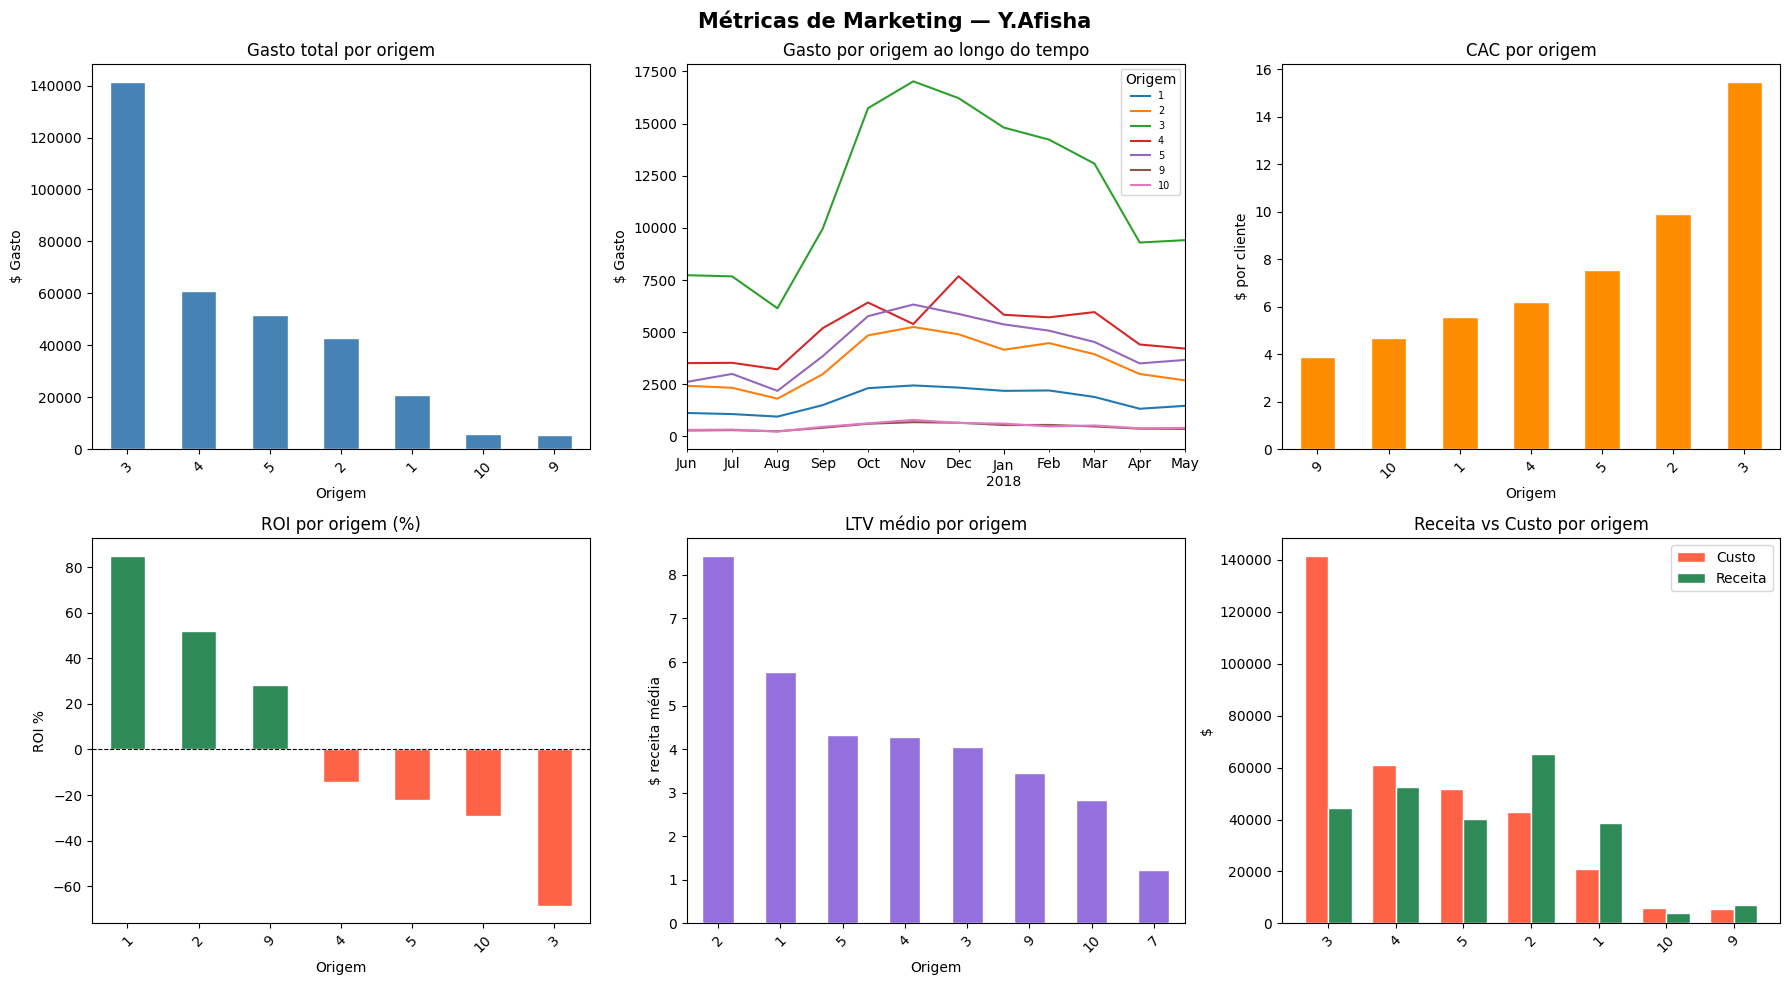


✅ Análise de marketing concluída!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ══════════════════════════════════════════════════════════════
# 1. GASTOS COM MARKETING
# ══════════════════════════════════════════════════════════════

print("═"*40)
print("  GASTOS TOTAIS COM MARKETING")
print("═"*40)
print(f"Total gasto : ${costs['costs'].sum():,.2f}")
print(f"Média mensal: ${costs.groupby(costs['dt'].dt.to_period('M'))['costs'].sum().mean():,.2f}")

# Gasto por origem
costs_by_source = costs.groupby('source_id')['costs'].sum().sort_values(ascending=False)
print("\nGasto por origem:")
print(costs_by_source.apply(lambda x: f"${x:,.2f}"))

# Gasto ao longo do tempo por origem
costs['month'] = costs['dt'].dt.to_period('M')
costs_time = costs.groupby(['month', 'source_id'])['costs'].sum().unstack(fill_value=0)

# ══════════════════════════════════════════════════════════════
# 2. CAC — CUSTO DE AQUISIÇÃO POR ORIGEM
# ══════════════════════════════════════════════════════════════

# Primeiro pedido de cada usuário
first_order = orders.groupby('uid')['buy_ts'].min().reset_index()
first_order.columns = ['uid', 'first_order_ts']

# Primeira visita de cada usuário com origem
first_visit = visits.groupby('uid').agg(
    first_visit_ts=('start_ts', 'min'),
    source_id=('source_id', 'first')  # origem da primeira visita
).reset_index()

# Usuários que compraram, com sua origem
buyers = first_visit.merge(first_order, on='uid')

# Total de compradores por origem
buyers_by_source = buyers.groupby('source_id')['uid'].count()

# CAC = custo total / nº de compradores por origem
cac = (costs_by_source / buyers_by_source).dropna().sort_values()

print("\n" + "═"*40)
print("  CAC POR ORIGEM")
print("═"*40)
for src, val in cac.items():
    print(f"  Origem {src}: ${val:.2f} por cliente")

# ══════════════════════════════════════════════════════════════
# 3. LTV E ROI POR ORIGEM
# ══════════════════════════════════════════════════════════════

# Receita total por origem (via usuários)
revenue_by_source = buyers.merge(orders, on='uid').groupby('source_id')['revenue'].sum()

# ROI = (receita - custo) / custo * 100
roi = ((revenue_by_source - costs_by_source) / costs_by_source * 100).dropna().sort_values(ascending=False)

print("\n" + "═"*40)
print("  ROI POR ORIGEM (%)")
print("═"*40)
for src, val in roi.items():
    status = "✅" if val > 0 else "❌"
    print(f"  {status} Origem {src}: {val:.1f}%")

# LTV médio por origem
ltv_by_source = buyers.merge(orders, on='uid').groupby('source_id')['revenue'].mean()
print("\n" + "═"*40)
print("  LTV MÉDIO POR ORIGEM")
print("═"*40)
for src, val in ltv_by_source.sort_values(ascending=False).items():
    print(f"  Origem {src}: ${val:.2f}")

# ══════════════════════════════════════════════════════════════
# 4. GRÁFICOS
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Métricas de Marketing — Y.Afisha', fontsize=15, fontweight='bold')

# 1. Gasto total por origem
costs_by_source.plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Gasto total por origem')
axes[0,0].set_xlabel('Origem')
axes[0,0].set_ylabel('$ Gasto')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Gasto ao longo do tempo (por origem)
costs_time.plot(ax=axes[0,1], linewidth=1.5)
axes[0,1].set_title('Gasto por origem ao longo do tempo')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('$ Gasto')
axes[0,1].legend(title='Origem', fontsize=7)

# 3. CAC por origem
cac.plot(kind='bar', ax=axes[0,2], color='darkorange', edgecolor='white')
axes[0,2].set_title('CAC por origem')
axes[0,2].set_xlabel('Origem')
axes[0,2].set_ylabel('$ por cliente')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. ROI por origem
colors = ['seagreen' if v > 0 else 'tomato' for v in roi.values]
roi.plot(kind='bar', ax=axes[1,0], color=colors, edgecolor='white')
axes[1,0].set_title('ROI por origem (%)')
axes[1,0].set_xlabel('Origem')
axes[1,0].set_ylabel('ROI %')
axes[1,0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. LTV por origem
ltv_by_source.sort_values(ascending=False).plot(kind='bar', ax=axes[1,1], color='mediumpurple', edgecolor='white')
axes[1,1].set_title('LTV médio por origem')
axes[1,1].set_xlabel('Origem')
axes[1,1].set_ylabel('$ receita média')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Receita vs Custo por origem
x = np.arange(len(costs_by_source.index))
width = 0.35
axes[1,2].bar(x - width/2, costs_by_source.values, width, label='Custo', color='tomato', edgecolor='white')
axes[1,2].bar(x + width/2, revenue_by_source.reindex(costs_by_source.index).values, width, label='Receita', color='seagreen', edgecolor='white')
axes[1,2].set_title('Receita vs Custo por origem')
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(costs_by_source.index, rotation=45)
axes[1,2].set_ylabel('$')
axes[1,2].legend()

plt.tight_layout()
plt.show()
print("\n✅ Análise de marketing concluída!")

Usuários por dispositivo:
device
desktop    164523
touch       71345
Name: uid, dtype: int64

Sessões por dispositivo:
device
desktop    262567
touch       96833
Name: uid, dtype: int64

Duração mediana da sessão por dispositivo (min):
device
desktop    6.0
touch      3.0
Name: session_duration, dtype: float64

Receita por dispositivo:
         receita_total  ticket_medio  num_pedidos
device                                           
desktop      211531.81      5.171421        40904
touch         40525.39      4.260897         9511

CAC estimado por dispositivo:
device
desktop     7.86
touch      13.64
Name: uid, dtype: float64


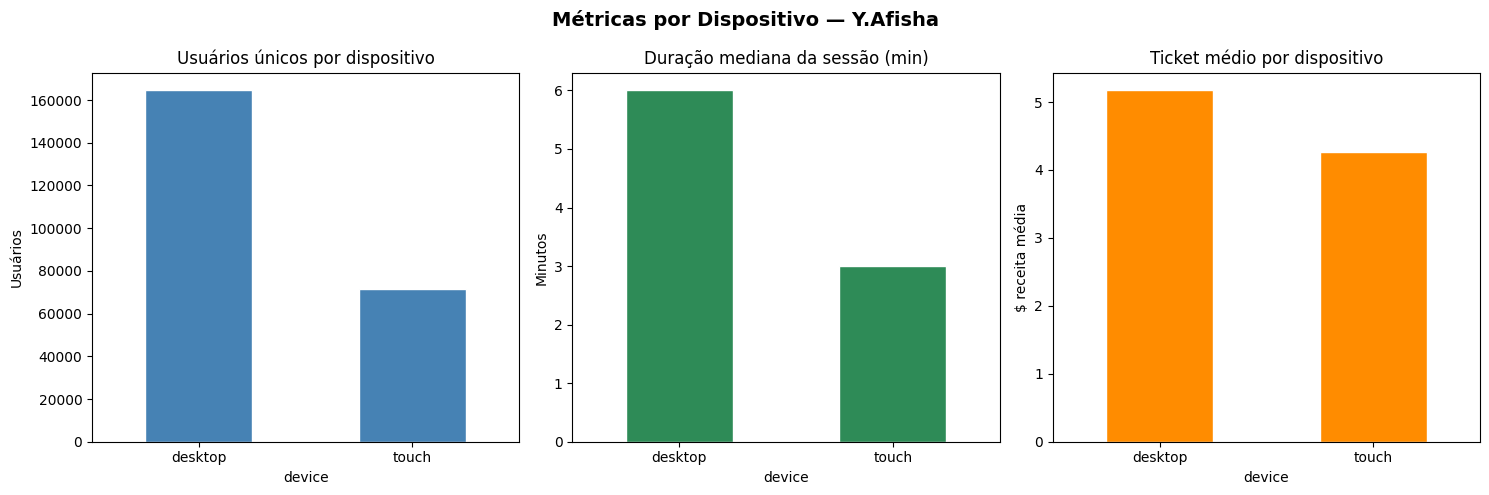

✅ Análise por dispositivo concluída!


In [ ]:
# ── MÉTRICAS POR DISPOSITIVO ──────────────────────────────────────────────────

# Usuários únicos por dispositivo
device_users = visits.groupby('device')['uid'].nunique()
print("Usuários por dispositivo:")
print(device_users)

# Sessões por dispositivo
device_sessions = visits.groupby('device')['uid'].count()
print("\nSessões por dispositivo:")
print(device_sessions)

# Duração média por dispositivo
device_duration = visits.groupby('device')['session_duration'].median() / 60
print("\nDuração mediana da sessão por dispositivo (min):")
print(device_duration.round(2))

# Pedidos por dispositivo (via merge com visits)
orders_device = visits[['uid','device']].drop_duplicates('uid').merge(orders, on='uid')
revenue_by_device = orders_device.groupby('device')['revenue'].agg(['sum','mean','count'])
revenue_by_device.columns = ['receita_total', 'ticket_medio', 'num_pedidos']
print("\nReceita por dispositivo:")
print(revenue_by_device)

# CAC por dispositivo
buyers_device = visits[['uid','device']].drop_duplicates('uid').merge(
    orders.groupby('uid')['buy_ts'].min().reset_index(), on='uid'
)
buyers_per_device = buyers_device.groupby('device')['uid'].count()

# Custo total (não temos device em costs, então dividimos proporcionalmente)
total_cost = costs['costs'].sum()
cost_share_by_device = (device_users / device_users.sum() * total_cost)
cac_device = cost_share_by_device / buyers_per_device
print("\nCAC estimado por dispositivo:")
print(cac_device.round(2))

# ── GRÁFICOS POR DISPOSITIVO ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Métricas por Dispositivo — Y.Afisha', fontsize=14, fontweight='bold')

device_users.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Usuários únicos por dispositivo')
axes[0].set_ylabel('Usuários')
axes[0].tick_params(axis='x', rotation=0)

device_duration.plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Duração mediana da sessão (min)')
axes[1].set_ylabel('Minutos')
axes[1].tick_params(axis='x', rotation=0)

revenue_by_device['ticket_medio'].plot(kind='bar', ax=axes[2], color='darkorange', edgecolor='white')
axes[2].set_title('Ticket médio por dispositivo')
axes[2].set_ylabel('$ receita média')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print("✅ Análise por dispositivo concluída!")

ROMI por Cohort
cohort_index         0     1     2     3     4     5     6     7     8     9     10    11
first_order_month                                                                        
2017-06            0.53  0.05  0.05  0.11  0.11  0.08  0.11  0.07  0.06  0.07  0.06  0.03
2017-07            0.63  0.04  0.07  0.04  0.02  0.02  0.01  0.01  0.02  0.02  0.02   NaN
2017-08            0.49  0.04  0.04  0.04  0.05  0.03  0.02  0.04  0.03  0.02   NaN   NaN
2017-09            0.60  0.12  0.06  0.42  0.04  0.07  0.07  0.03  0.02   NaN   NaN   NaN
2017-10            0.60  0.06  0.02  0.02  0.02  0.01  0.01  0.01   NaN   NaN   NaN   NaN
2017-11            0.55  0.04  0.02  0.03  0.02  0.01  0.01   NaN   NaN   NaN   NaN   NaN
2017-12            0.54  0.03  0.11  0.12  0.04  0.04   NaN   NaN   NaN   NaN   NaN   NaN
2018-01            0.42  0.03  0.03  0.01  0.01   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2018-02            0.46  0.03  0.01  0.01   NaN   NaN   NaN   NaN   NaN   NaN   NaN 

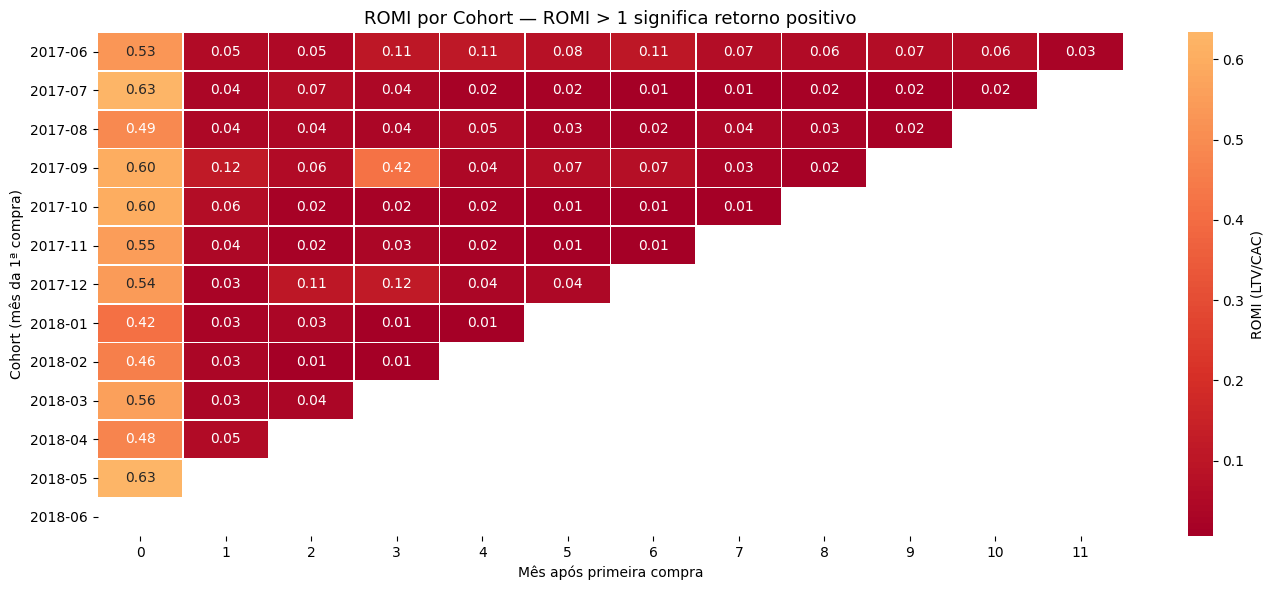


ROMI médio por origem (source_id):
             ltv    cac  romi
source_id                    
1          10.72   7.19  1.49
2          13.38  12.21  1.10
3           5.20  13.49  0.39
4           5.51   5.93  0.93
5           7.59   7.47  1.02
7           1.22   0.00   inf
9           5.29   5.07  1.04
10          3.35   4.38  0.76


In [ ]:


# ── ROMI por cohort ───────────────────────────────────────────────────────────

# Receita acumulada por usuário ao longo dos meses do cohort
orders['order_month'] = orders['buy_ts'].dt.to_period('M')

# Juntar ordens com info do usuário (cohort_month e source_id)
orders_full = orders.merge(user_info[['uid', 'cohort_month', 'source_id']], on='uid', how='left')

# Índice do mês dentro do cohort
orders_full['cohort_index'] = (
    orders_full['order_month'] - orders_full['cohort_month']
).apply(lambda x: x.n)

# Receita acumulada por cohort e índice de mês
revenue_cohort = (
    orders_full.groupby(['cohort_month', 'cohort_index'])['revenue']
    .sum()
    .reset_index()
)

# Custo total por cohort (somando todos os sources)
costs['month'] = costs['dt'].dt.to_period('M')
costs_cohort = (
    costs.groupby('month')['costs']
    .sum()
    .reset_index()
)
costs_cohort.columns = ['cohort_month', 'total_costs']

# Número de usuários por cohort
users_cohort = (
    user_info.groupby('cohort_month')['uid']
    .nunique()
    .reset_index()
)
users_cohort.columns = ['cohort_month', 'n_users']

# Juntar tudo
romi_df = revenue_cohort.merge(costs_cohort, on='cohort_month', how='left')
romi_df = romi_df.merge(users_cohort, on='cohort_month', how='left')

# Calcular LTV e CAC acumulados
romi_df['ltv'] = romi_df['revenue'] / romi_df['n_users']
romi_df['cac'] = romi_df['total_costs'] / romi_df['n_users']

# ROMI = LTV / CAC
romi_df['romi'] = romi_df['ltv'] / romi_df['cac']

# ── Pivot table de ROMI ───────────────────────────────────────────────────────
romi_pivot = romi_df.pivot(index='cohort_month', columns='cohort_index', values='romi')
romi_pivot.index.name = 'first_order_month'

print("ROMI por Cohort")
print(romi_pivot.iloc[:, :12].round(2).to_string())

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    romi_pivot.iloc[:, :12],
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=1.0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'ROMI (LTV/CAC)'}
)
ax.set_title('ROMI por Cohort — ROMI > 1 significa retorno positivo', fontsize=13)
ax.set_xlabel('Mês após primeira compra')
ax.set_ylabel('Cohort (mês da 1ª compra)')
ax.yaxis.set_tick_params(rotation=0)
plt.tight_layout()
plt.show()

# ── ROMI por origem ───────────────────────────────────────────────────────────
print("\nROMI médio por origem (source_id):")
print("="*40)
romi_by_source = (
    ltv_cac.groupby('source_id')[['revenue', 'costs', 'n_users']]
    .sum()
    .assign(
        ltv=lambda x: x['revenue'] / x['n_users'],
        cac=lambda x: x['costs']  / x['n_users'],
        romi=lambda x: (x['revenue'] / x['n_users']) / (x['costs'] / x['n_users'])
    )
    [['ltv', 'cac', 'romi']]
    .round(2)
)
print(romi_by_source.to_string())


Retenção — o problema central
A análise de cohort revelou o dado mais crítico do projeto: apenas 3,7% dos clientes retornam no mês seguinte à primeira compra, caindo para ~2% nos meses subsequentes. Isso significa que a base de clientes é essencialmente descartável — o negócio depende quase inteiramente da aquisição contínua de novos usuários para manter o faturamento.
Esse padrão torna o CAC ainda mais importante: como os clientes raramente voltam, cada real gasto para adquiri-los precisa se pagar na primeira compra.

 Comportamento dos usuários

80% visitam apenas uma vez e não retornam
Mediana de conversão: 0 dias — quem compra, compra no mesmo dia da visita
Sessões curtas (~5 min) indicam intenção objetiva de compra

O produto converte bem quem já chega decidido. O gargalo está na qualidade e no custo dos canais de aquisição.

 ROMI por cohort
 
A análise de ROMI por cohort mostrou que nenhum cohort atingiu ROMI ≥ 1 no mês de aquisição (Mês 0), o que indica que a empresa não recupera o custo de aquisição na primeira compra. Dado que a retenção é de ~2–3%, a maioria dos cohorts nunca chega a recuperar o investimento ao longo do tempo.
Os cohorts de junho e julho/2017 apresentaram os melhores ROMI acumulados, sugerindo que as condições de aquisição nesse período eram mais favoráveis — vale investigar quais canais e campanhas estavam ativos nessa época.

Origem 3 concentra 43% do orçamento e tem o pior ROMI de toda a base — CAC alto e LTV insuficiente para cobrir o investimento em nenhum cohort analisado.

 Recomendações
 
Corte imediato: reduzir 70%+ do orçamento da Origem 3. É o canal que mais consome verba e menos retorna — em nenhum cohort apresentou ROMI positivo.

Escalar com cautela: Origens 1 e 9 têm o melhor equilíbrio entre CAC baixo e ROMI positivo. São os candidatos naturais para receber o budget realocado.

Priorizar desktop: CAC 73% menor que mobile, responsável por 84% da receita. Antes de qualquer investimento adicional em mobile, auditar a UX para identificar o que prejudica a conversão.
Trabalhar retenção: com cohorts retendo apenas 2–3% ao mês, qualquer melhoria aqui tem impacto direto no LTV e no ROMI. Programas de recompra, e-mail marketing pós-compra e cupons de retorno são pontos de partida.

Conclusão final

A Y.Afisha tem um produto que converte bem — quem visita com intenção de compra, compra no mesmo dia. O problema está em dois pontos: alocação de orçamento e retenção. Quase metade da verba vai para o canal de pior desempenho (Origem 3), enquanto os canais mais rentáveis ficam subfinanciados. Ao mesmo tempo, a retenção de ~2% ao mês faz com que nenhum cohort consiga acumular LTV suficiente para cobrir o CAC ao longo do tempo. Corrigir a alocação orçamentária e investir em retenção são as duas alavancas com maior potencial de impacto no retorno de marketing da empresa.